<div style="font-size: 2em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Moyenne par quart d'heure - RMSE public : 4.8022
</div>
<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Importation des bilbiothèques
</div>

In [1]:
import pandas as pd
import numpy as np

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Importation des documents de données temporelles et de test
</div>

In [2]:
history_toulouse_train = pd.read_parquet("history_toulouse_train.parquet")
history_toulouse_test = pd.read_parquet("history_toulouse_test.parquet")

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Création d'un dataset de test pour évaluer sa performance
</div>
On récupère les 8 dernières valeurs

In [3]:
rang_depuis_la_fin = history_toulouse_train.groupby(level="station").cumcount(ascending=False)
history_toulouse_apprentissage = history_toulouse_train[rang_depuis_la_fin >= 8].copy()

On créé l'ensemble de validation avec la dernière valeur connue + les 8 à prédire

In [4]:
last_9 = history_toulouse_train.groupby(level="station").tail(9).copy()

On remet l'index sous forme de colonnes

In [5]:
last_9 = last_9.reset_index()

On calule la somme cummulée

In [6]:
last_9["horizon"] = last_9.groupby("station").cumcount()

On crée une ligne par station et on récupère les 8 valeurs futures

In [7]:
history_toulouse_validation = (
    last_9
    .pivot(
        index="station",
        columns="horizon",
        values="bikes"
    )
    .drop(columns=0)
    .rename(columns={
        1: "bikes_+15min",
        2: "bikes_+30min",
        3: "bikes_+45min",
        4: "bikes_+60min",
        5: "bikes_+75min",
        6: "bikes_+90min",
        7: "bikes_+105min",
        8: "bikes_+120min"
    })
)

Récupérer la date de la dernière mesure de l'ensemble d'apprentissage par station

In [8]:
cutoff_times = last_9[last_9["horizon"] == 0].set_index("station")["commit_at"]

Ajouter commit_at

In [9]:
history_toulouse_validation["commit_at"] = cutoff_times

Mettre station + commit_at en MultiIndex

In [10]:
history_toulouse_validation = history_toulouse_validation.reset_index().set_index(["station", "commit_at"]).sort_index()

history_toulouse_validation

,horizon,bikes_+15min,bikes_+30min,bikes_+45min,bikes_+60min,bikes_+75min,bikes_+90min,bikes_+105min,bikes_+120min
station,commit_at,,,,,,,,
00001 - POIDS DE L'HUILE,2026-07-31 19:45:00,1.0,1.0,1.0,1.0,1.0,1.0,9.0,9.0
00002 - LAFAYETTE,2026-07-31 21:45:00,5.0,5.0,5.0,9.0,9.0,9.0,9.0,9.0
00003 - ALSACE - LORRAINE - POMME,2025-11-10 09:45:00,9.0,12.0,15.0,16.0,17.0,17.0,17.0,18.0
00003 - ALSACE-LORRAINE - POMME,2026-07-31 19:45:00,0.0,0.0,0.0,0.0,0.0,0.0,12.0,12.0
00003 - POMME,2025-01-05 03:45:00,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0
...,...,...,...,...,...,...,...,...,...
NARBONNE - CLOTASSES,2025-08-22 17:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PASTEUR - LAVOISIER,2025-08-05 08:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PLACE GEORGES BRASSENS,2025-08-05 09:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Prédictions
</div>
On convertit les indexe en colonnes classiques

In [11]:
train = history_toulouse_apprentissage.reset_index()

On convertit les chaines de caractère en format date en on extrait les heures et les minutes

In [12]:
train["heure"] = train["commit_at"].dt.hour
train["minutes"] = train["commit_at"].dt.minute

Moyenne par quart d'heure de chaque station

In [13]:
moyenne_station_heure = train.groupby(["station", "heure", "minutes"])["bikes"].mean().round().astype(int)

Moyenne totale de la station en cas de valeurs manquantes

In [14]:
moyenne_station = train.groupby("station")["bikes"].mean().round().astype(int)

On extrait tous les indexe station et commit_at_index sous forme de liste

In [15]:
station_index = history_toulouse_test.index.get_level_values("station")
commit_at_index = history_toulouse_test.index.get_level_values("commit_at")

On associe chaque nom de colonne à une valeur numérique

In [16]:
decalage = {
    "bikes_+15min": 15,
    "bikes_+30min": 30,
    "bikes_+45min": 45,
    "bikes_+60min": 60,
    "bikes_+75min": 75,
    "bikes_+90min": 90,
    "bikes_+105min": 105,
    "bikes_+120min": 120,
}

On procède pour chaque décalage individuellement

In [17]:
for col, m in decalage.items():
    # Instant cible = commit_at + h minutes
    heure_cible = (commit_at_index + pd.Timedelta(minutes=m)).hour
    minute_cible = (commit_at_index + pd.Timedelta(minutes=m)).minute
    # On relie chaque station à son heure
    cle = list(zip(station_index, heure_cible, minute_cible))
    # On associe chaque (station_index, heure_cible, minute_cible) à la moyenne horaire du nombre de vélos
    valeurs = pd.Series(cle, index=history_toulouse_test.index).map(moyenne_station_heure)
    # En cas de valeur manquante, on utilise la moyenne totale de la station
    valeurs = valeurs.fillna(pd.Series(station_index, index=history_toulouse_test.index).map(moyenne_station)).fillna(moyenne_station.mean())
    # On sauvegarde le résultat en tant qu'entier
    history_toulouse_test[col] = valeurs.astype(int)

Calcul du score RMSE

In [18]:
rmse = np.sqrt(np.nanmean((history_toulouse_test.values - history_toulouse_validation.values)**2))
print(f'RMSE',rmse)

RMSE 5.642198408417584


<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
On recalcule tout avec TOUTES les données d'entraînement fournies
</div>

In [19]:
train = history_toulouse_train.reset_index()
train["heure"] = train["commit_at"].dt.hour
train["minutes"] = train["commit_at"].dt.minute
moyenne_station_heure = train.groupby(["station", "heure", "minutes"])["bikes"].mean().round().astype(int)
moyenne_station = train.groupby("station")["bikes"].mean().round().astype(int)
station_index = history_toulouse_test.index.get_level_values("station")
commit_at_index = history_toulouse_test.index.get_level_values("commit_at")
for col, m in decalage.items():
    # Instant cible = commit_at + h minutes
    heure_cible = (commit_at_index + pd.Timedelta(minutes=m)).hour
    minute_cible = (commit_at_index + pd.Timedelta(minutes=m)).minute
    # On relie chaque station à son heure
    cle = list(zip(station_index, heure_cible, minute_cible))
    # On associe chaque (station_index, heure_cible, minute_cible) à la moyenne horaire du nombre de vélos
    valeurs = pd.Series(cle, index=history_toulouse_test.index).map(moyenne_station_heure)
    # En cas de valeur manquante, on utilise la moyenne totale de la station
    valeurs = valeurs.fillna(pd.Series(station_index, index=history_toulouse_test.index).map(moyenne_station))
    # On sauvegarde le résultat en tant qu'entier
    history_toulouse_test[col] = valeurs.astype(int)

<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Sauvegarde du résultat
</div>

In [20]:
history_toulouse_test.to_parquet("BA_prediction_3_quart_heure.parquet", index=True)
history_toulouse_test

,horizon,bikes_+15min,bikes_+30min,bikes_+45min,bikes_+60min,bikes_+75min,bikes_+90min,bikes_+105min,bikes_+120min
station,commit_at,,,,,,,,
00001 - POIDS DE L'HUILE,2026-07-31 21:45:00,4,4,4,3,3,3,3,3
00002 - LAFAYETTE,2026-07-31 23:45:00,5,5,5,5,4,4,4,4
00003 - ALSACE - LORRAINE - POMME,2025-11-10 11:45:00,11,11,11,10,10,10,9,9
00003 - ALSACE-LORRAINE - POMME,2026-07-31 21:45:00,4,4,4,3,3,2,2,2
00003 - POMME,2025-01-05 05:45:00,8,8,8,8,8,9,9,9
...,...,...,...,...,...,...,...,...,...
NARBONNE - CLOTASSES,2025-08-22 19:15:00,0,0,0,0,0,0,0,0
PASTEUR - LAVOISIER,2025-08-05 10:15:00,0,0,0,0,0,0,0,0
PLACE GEORGES BRASSENS,2025-08-05 11:00:00,0,0,0,0,0,0,0,0


<div style="font-size: 1em; font-weight: bold; margin-top: 0.67em; margin-bottom: 0.67em;">
Affichage de la courbe pour une station
</div>

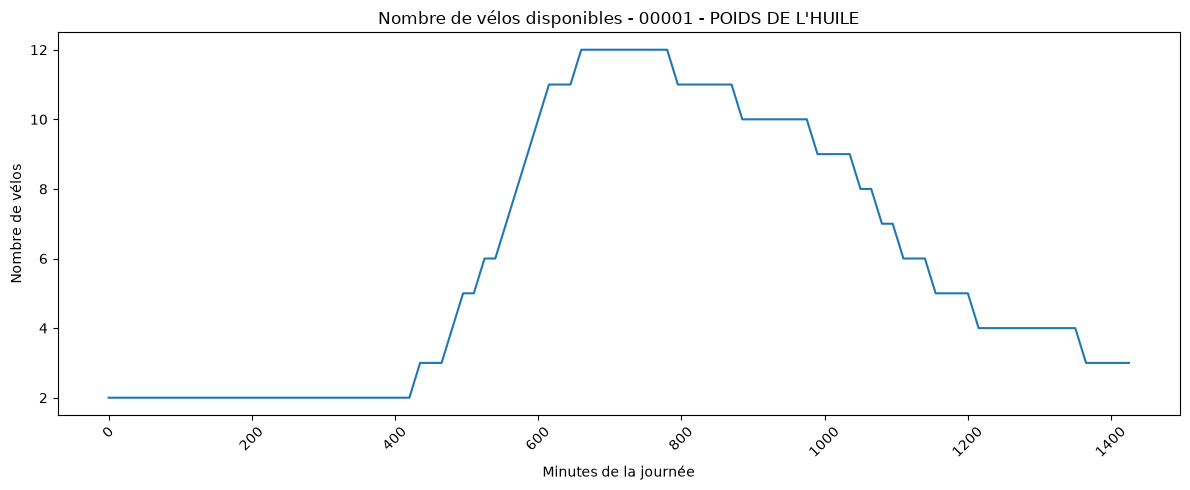

In [21]:
import matplotlib.pyplot as plt

# Nom d'une station que l'on souhaite étudier
station = "00001 - POIDS DE L'HUILE"

# Sélection de toutes les observations de cette station
donnees_station = moyenne_station_heure.loc[station]
liste_minutes = [heure * 60 + minute for heure, minute in donnees_station.index]

plt.figure(figsize=(12, 5))

plt.plot(
    liste_minutes,   # les dates de mesure
    donnees_station.values   # le nombre de vélos
)

plt.xlabel("Minutes de la journée")
plt.ylabel("Nombre de vélos")
plt.title(f"Nombre de vélos disponibles - {station}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()